In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version PyTorch is using: {torch.version.cuda}")
print(f"Is the GPU recognized? {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cu130
CUDA version PyTorch is using: 13.0
Is the GPU recognized? True


In [2]:
import os
import gc
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    cohen_kappa_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torchvision.transforms import InterpolationMode

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

## Configuration

In [ ]:
ZIP_PATH = Path("train_processed_final.zip")
LABELS_CSV = Path("trainLabels.csv")
EXTRACT_DIR = Path("train_processed_data")
MODEL_SAVE_PATH = Path("best_convnext_tiny_ordinal.pth")
HISTORY_SAVE_PATH = Path("training_history_ordinal.csv")

SEED = 42
NUM_CLASSES = 5
NUM_THRESHOLDS = NUM_CLASSES - 1  # cumulative ordinal head outputs 4 logits for classes 0..4

IMG_SIZE = 320
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4
EFFECTIVE_BATCH_SIZE = BATCH_SIZE * GRAD_ACCUM_STEPS

NUM_EPOCHS = 18
BACKBONE_FREEZE_EPOCHS = 1
EARLY_STOPPING_PATIENCE = 5

LR_BACKBONE = 2e-5
LR_HEAD = 1e-4
WEIGHT_DECAY = 2e-4
ORDINAL_TARGET_SMOOTHING = 0.02
MAX_GRAD_NORM = 1.0

USE_POS_WEIGHTED_BCE = True
ENABLE_THRESHOLD_TUNING = True
USE_CHANNELS_LAST = True

VAL_SIZE = 0.2
NUM_WORKERS = 0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print(f"IMG_SIZE={IMG_SIZE}, batch={BATCH_SIZE}, accum={GRAD_ACCUM_STEPS}, effective_batch={EFFECTIVE_BATCH_SIZE}")


In [4]:
if not EXTRACT_DIR.exists():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

Dataset already extracted.


In [5]:
labels_df = pd.read_csv(LABELS_CSV)
print(labels_df.head())
print(labels_df.columns.tolist())

      image  level
0   10_left      0
1  10_right      0
2   13_left      0
3  13_right      0
4   15_left      1
['image', 'level']


## Image path mapping

In [6]:
image_files = list(EXTRACT_DIR.rglob("*.jpg")) + list(EXTRACT_DIR.rglob("*.jpeg")) + list(EXTRACT_DIR.rglob("*.png"))
print("Total extracted image files:", len(image_files))
image_map = {img.stem: img for img in image_files}
print("Mapped image stems:", len(image_map))

Total extracted image files: 35126
Mapped image stems: 35126


## Match labels with available images

In [7]:
labels_df["image_path"] = labels_df["image"].map(image_map)
labels_df = labels_df.dropna(subset=["image_path"]).copy()

labels_df["image_path"] = labels_df["image_path"].astype(str)
labels_df["level"] = labels_df["level"].astype(int)

print("Matched samples:", len(labels_df))
print(labels_df["level"].value_counts().sort_index())
labels_df.head()

Matched samples: 35126
level
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64


,image,level,image_path
0,10_left,0,train_processed_data/10_left.jpg
1,10_right,0,train_processed_data/10_right.jpg
2,13_left,0,train_processed_data/13_left.jpg
3,13_right,0,train_processed_data/13_right.jpg
4,15_left,1,train_processed_data/15_left.jpg


In [8]:
train_df, val_df = train_test_split(
    labels_df,
    test_size = VAL_SIZE,
    stratify = labels_df["level"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

Train size: 28100
Val size: 7026


In [9]:
train_df.to_csv("train_dataset.csv", index=False)
val_df.to_csv("val_dataset.csv", index=False)

In [10]:
train_df = pd.read_csv("train_dataset.csv")   
val_df = pd.read_csv("val_dataset.csv")   

## Data Augmentation

In [11]:
train_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.08), interpolation=InterpolationMode.BILINEAR),
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.92, 1.0),
        ratio=(0.95, 1.05),
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.08,
            contrast=0.08,
            saturation=0.03,
            hue=0.01
        )
    ], p=0.5),
    transforms.RandomAffine(
        degrees=8,
        translate=(0.03, 0.03),
        scale=(0.97, 1.03),
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.05), interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Creating Dataset

In [ ]:
def label_to_ordinal_targets(labels, num_classes=NUM_CLASSES):
    """Encode labels as cumulative ordinal targets.

    0 -> [0,0,0,0], 1 -> [1,0,0,0], ..., 4 -> [1,1,1,1].
    """
    labels = torch.as_tensor(labels, dtype=torch.long)
    thresholds = torch.arange(num_classes - 1, device=labels.device)
    return (labels.unsqueeze(-1) > thresholds).float()


def ordinal_logits_to_probs(logits):
    return torch.sigmoid(logits)


def ordinal_probs_to_class(probs, thresholds=0.5):
    thresholds = torch.as_tensor(thresholds, device=probs.device, dtype=probs.dtype)
    if thresholds.ndim == 0:
        thresholds = thresholds.repeat(probs.shape[1])
    # Decode by counting how many cumulative thresholds are passed.
    return (probs >= thresholds.unsqueeze(0)).sum(dim=1).long().clamp(0, NUM_CLASSES - 1)


class DRDataset(Dataset):
    def __init__(self, df, transform=None, return_ordinal=True):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.return_ordinal = return_ordinal

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]
        label = int(row["level"])
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Failed to load image: {img_path}") from e

        if self.transform:
            image = self.transform(image)

        if self.return_ordinal:
            ordinal_target = label_to_ordinal_targets(label)
            return image, ordinal_target, label

        return image, label


train_dataset = DRDataset(train_df, transform=train_transform, return_ordinal=True)
val_dataset = DRDataset(val_df, transform=val_transform, return_ordinal=True)


## Handling Class Imbalance
Ref: <href>https://www.geeksforgeeks.org/deep-learning/handling-class-imbalance-in-pytorch/</href>

In [ ]:
class_counts = (
    train_df["level"]
    .value_counts()
    .sort_index()
    .reindex(range(NUM_CLASSES), fill_value=0)
    .values
)

train_labels_np = train_df["level"].to_numpy(dtype=np.int64)
train_ordinal_targets_np = (train_labels_np[:, None] > np.arange(NUM_THRESHOLDS)[None, :]).astype(np.float32)

positive_counts = train_ordinal_targets_np.sum(axis=0)
negative_counts = len(train_ordinal_targets_np) - positive_counts

# Per-threshold positive weighting handles imbalance without WeightedRandomSampler.
# The sqrt keeps rare high-grade thresholds from dominating BCE updates.
pos_weight_np = np.sqrt(negative_counts / np.clip(positive_counts, a_min=1, a_max=None))
pos_weight_np = np.clip(pos_weight_np, 0.5, 8.0)
ordinal_pos_weight = torch.tensor(pos_weight_np, dtype=torch.float32, device=DEVICE)

print("Class counts:", class_counts.tolist())
print("Ordinal positive counts per threshold y>k:", positive_counts.astype(int).tolist())
print("Ordinal BCE pos_weight:", ordinal_pos_weight.detach().cpu().numpy().round(3).tolist())
print("Using shuffled batches plus per-threshold BCE pos_weight; WeightedRandomSampler remains off for stabler calibration and QWK tuning.")


## Data Loaders
Ref: <href>https://docs.pytorch.org/docs/stable/data.html</href>

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0)
)

## Loading ConvNeXt-Tiny
Using pre-trained weights

In [ ]:
weights = ConvNeXt_Tiny_Weights.DEFAULT


def build_model(num_thresholds=NUM_THRESHOLDS):
    model = convnext_tiny(weights=weights)
    in_features = model.classifier[2].in_features
    # Single cumulative ordinal head: four logits model P(level > 0), ..., P(level > 3).
    model.classifier[2] = nn.Sequential(
        nn.Dropout(p=0.20),
        nn.Linear(in_features, num_thresholds)
    )
    return model


def set_backbone_trainable(model, trainable=True):
    for param in model.features.parameters():
        param.requires_grad = trainable
    for param in model.classifier.parameters():
        param.requires_grad = True


model = build_model().to(DEVICE)
if USE_CHANNELS_LAST and DEVICE.type == "cuda":
    model = model.to(memory_format=torch.channels_last)
set_backbone_trainable(model, trainable=False)
print(model)
print("Backbone frozen for warm-up epoch(s):", BACKBONE_FREEZE_EPOCHS)


## Loss, Optimizer, Scheduler, Mixed Precision

In [ ]:
class CumulativeOrdinalLoss(nn.Module):
    """BCEWithLogitsLoss over cumulative ordinal targets."""

    def __init__(self, pos_weight=None, target_smoothing=0.0):
        super().__init__()
        self.target_smoothing = target_smoothing
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def forward(self, logits, ordinal_targets):
        ordinal_targets = ordinal_targets.to(device=logits.device, dtype=logits.dtype)
        if self.target_smoothing > 0:
            smooth = self.target_smoothing
            ordinal_targets = ordinal_targets * (1.0 - smooth) + 0.5 * smooth
        return self.bce(logits, ordinal_targets)


def build_criterion():
    pos_weight = ordinal_pos_weight if USE_POS_WEIGHTED_BCE else None
    return CumulativeOrdinalLoss(
        pos_weight=pos_weight,
        target_smoothing=ORDINAL_TARGET_SMOOTHING
    )


criterion = build_criterion().to(DEVICE)

optimizer = optim.AdamW(
    [
        {"params": model.features.parameters(), "lr": LR_BACKBONE},
        {"params": model.classifier.parameters(), "lr": LR_HEAD},
    ],
    weight_decay=WEIGHT_DECAY
)

warmup_scheduler = optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.25,
    total_iters=max(1, BACKBONE_FREEZE_EPOCHS)
)
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(1, NUM_EPOCHS - BACKBONE_FREEZE_EPOCHS),
    eta_min=1e-6
)
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[max(1, BACKBONE_FREEZE_EPOCHS)]
)

scaler = torch.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

print("Loss config:")
print("  Cumulative ordinal BCEWithLogitsLoss")
print(f"  pos_weight={USE_POS_WEIGHTED_BCE}, target_smoothing={ORDINAL_TARGET_SMOOTHING}")


## Model Training

In [ ]:
def quadratic_weighted_kappa(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights="quadratic")


def compute_metrics(y_true, y_pred):
    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="weighted"),
        "qwk": quadratic_weighted_kappa(y_true, y_pred),
    }


def apply_probability_thresholds(ordinal_probs, thresholds=None):
    ordinal_probs = np.asarray(ordinal_probs, dtype=np.float32)
    thresholds = np.asarray(
        [0.5] * NUM_THRESHOLDS if thresholds is None else thresholds,
        dtype=np.float32
    )
    thresholds = np.clip(thresholds, 0.05, 0.95)
    return (ordinal_probs >= thresholds.reshape(1, -1)).sum(axis=1).clip(0, NUM_CLASSES - 1).astype(int)


def optimize_probability_thresholds(y_true, ordinal_probs, initial_thresholds=None, start_step=0.08, min_step=0.005):
    """Tune the four sigmoid cutoffs on validation QWK.

    Each cutoff is for one cumulative output P(level > k); predictions are decoded
    by counting passed thresholds, so final labels stay in 0..4.
    """
    y_true = np.asarray(y_true, dtype=np.int64)
    ordinal_probs = np.asarray(ordinal_probs, dtype=np.float32)
    thresholds = np.asarray(
        initial_thresholds if initial_thresholds is not None else [0.5] * NUM_THRESHOLDS,
        dtype=np.float32
    )
    thresholds = np.clip(thresholds, 0.05, 0.95)

    best_qwk = quadratic_weighted_kappa(y_true, apply_probability_thresholds(ordinal_probs, thresholds))
    step = start_step

    while step >= min_step:
        improved = False
        for idx in range(NUM_THRESHOLDS):
            candidates = np.arange(
                max(0.05, thresholds[idx] - (2 * step)),
                min(0.95, thresholds[idx] + (2 * step)) + (step * 0.5),
                step,
                dtype=np.float32
            )
            local_best = thresholds[idx]
            local_best_qwk = best_qwk

            for candidate in candidates:
                trial = thresholds.copy()
                trial[idx] = candidate
                trial_qwk = quadratic_weighted_kappa(y_true, apply_probability_thresholds(ordinal_probs, trial))
                if trial_qwk > local_best_qwk:
                    local_best_qwk = trial_qwk
                    local_best = candidate

            if local_best_qwk > best_qwk:
                thresholds[idx] = local_best
                best_qwk = local_best_qwk
                improved = True

        if not improved:
            step *= 0.5

    return np.clip(thresholds, 0.05, 0.95), best_qwk


def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(loader, desc="Training", leave=False, dynamic_ncols=True)

    for step_idx, (images, ordinal_targets, labels) in enumerate(pbar, start=1):
        images = images.to(device, non_blocking=True)
        ordinal_targets = ordinal_targets.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if USE_CHANNELS_LAST and device.type == "cuda":
            images = images.contiguous(memory_format=torch.channels_last)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            logits = model(images)
            raw_loss = criterion(logits, ordinal_targets)
            loss = raw_loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        if step_idx % GRAD_ACCUM_STEPS == 0 or step_idx == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += raw_loss.item() * images.size(0)

        probs = ordinal_logits_to_probs(logits)
        preds = ordinal_probs_to_class(probs)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        pbar.set_postfix(loss=f"{raw_loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_metrics = compute_metrics(all_labels, all_preds)
    return epoch_loss, epoch_metrics


def validate_one_epoch(model, loader, criterion, device, decode_thresholds=None):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    all_expected_scores = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Validation", leave=False, dynamic_ncols=True)

        for images, ordinal_targets, labels in pbar:
            images = images.to(device, non_blocking=True)
            ordinal_targets = ordinal_targets.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if USE_CHANNELS_LAST and device.type == "cuda":
                images = images.contiguous(memory_format=torch.channels_last)

            with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
                logits = model(images)
                loss = criterion(logits, ordinal_targets)

            probs = ordinal_logits_to_probs(logits)
            preds = ordinal_probs_to_class(probs, thresholds=0.5 if decode_thresholds is None else decode_thresholds)
            expected_scores = probs.sum(dim=1)

            running_loss += loss.item() * images.size(0)

            all_probs.extend(probs.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            all_expected_scores.extend(expected_scores.detach().cpu().numpy())

            pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_metrics = compute_metrics(all_labels, all_preds)

    return (
        epoch_loss,
        epoch_metrics,
        np.asarray(all_labels),
        np.asarray(all_preds),
        np.asarray(all_probs),
        np.asarray(all_expected_scores),
    )


In [ ]:
history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "train_qwk": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "val_qwk": [],
    "val_default_qwk": [],
    "lr_backbone": [],
    "lr_head": [],
}

best_val_qwk = -1.0
best_thresholds = np.array([0.5] * NUM_THRESHOLDS, dtype=np.float32)
epochs_without_improvement = 0

if DEVICE.type == "cuda":
    gc.collect()
    torch.cuda.empty_cache()

for epoch in range(NUM_EPOCHS):
    if epoch == BACKBONE_FREEZE_EPOCHS:
        set_backbone_trainable(model, trainable=True)
        if DEVICE.type == "cuda":
            gc.collect()
            torch.cuda.empty_cache()
        print("\nBackbone unfrozen. Fine-tuning full ConvNeXt-Tiny.")

    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")

    train_loss, train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, DEVICE
    )

    (
        val_loss,
        val_default_metrics,
        val_labels,
        val_default_preds,
        val_ordinal_probs,
        val_expected_scores,
    ) = validate_one_epoch(model, val_loader, criterion, DEVICE)

    if ENABLE_THRESHOLD_TUNING:
        current_thresholds, tuned_qwk = optimize_probability_thresholds(
            val_labels,
            val_ordinal_probs,
            initial_thresholds=best_thresholds
        )
        val_preds = apply_probability_thresholds(val_ordinal_probs, current_thresholds)
        val_metrics = compute_metrics(val_labels, val_preds)
    else:
        current_thresholds = np.array([0.5] * NUM_THRESHOLDS, dtype=np.float32)
        tuned_qwk = val_default_metrics["qwk"]
        val_preds = val_default_preds
        val_metrics = val_default_metrics

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_metrics["acc"])
    history["train_f1"].append(train_metrics["f1"])
    history["train_qwk"].append(train_metrics["qwk"])
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_metrics["acc"])
    history["val_f1"].append(val_metrics["f1"])
    history["val_qwk"].append(val_metrics["qwk"])
    history["val_default_qwk"].append(val_default_metrics["qwk"])
    history["lr_backbone"].append(optimizer.param_groups[0]["lr"])
    history["lr_head"].append(optimizer.param_groups[1]["lr"])

    print(
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_metrics['acc']:.4f} | "
        f"Train F1: {train_metrics['f1']:.4f} | Train QWK: {train_metrics['qwk']:.4f}"
    )
    print(
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_metrics['acc']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | Val QWK: {val_metrics['qwk']:.4f} | "
        f"Default-threshold QWK: {val_default_metrics['qwk']:.4f}"
    )
    print("Sigmoid thresholds:", np.round(current_thresholds, 3).tolist())
    print(
        f"LRs -> backbone: {optimizer.param_groups[0]['lr']:.2e}, "
        f"head: {optimizer.param_groups[1]['lr']:.2e}"
    )

    if val_metrics["qwk"] > best_val_qwk:
        best_val_qwk = val_metrics["qwk"]
        best_thresholds = current_thresholds.copy()
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "thresholds": best_thresholds.tolist(),
                "best_val_metrics": {k: float(v) for k, v in val_metrics.items()},
                "best_val_default_metrics": {k: float(v) for k, v in val_default_metrics.items()},
                "ordinal_setup": {
                    "num_classes": NUM_CLASSES,
                    "num_thresholds": NUM_THRESHOLDS,
                    "target_encoding": "class k -> [1 if k > threshold else 0 for thresholds 0..3]",
                    "decode": "sigmoid(logits), then count thresholds passed",
                },
                "config": {
                    "img_size": IMG_SIZE,
                    "batch_size": BATCH_SIZE,
                    "grad_accum_steps": GRAD_ACCUM_STEPS,
                    "num_epochs": NUM_EPOCHS,
                    "freeze_epochs": BACKBONE_FREEZE_EPOCHS,
                    "lr_backbone": LR_BACKBONE,
                    "lr_head": LR_HEAD,
                    "weight_decay": WEIGHT_DECAY,
                    "ordinal_target_smoothing": ORDINAL_TARGET_SMOOTHING,
                    "use_pos_weighted_bce": USE_POS_WEIGHTED_BCE,
                    "enable_threshold_tuning": ENABLE_THRESHOLD_TUNING,
                },
            },
            MODEL_SAVE_PATH
        )
        print(f"Best model saved based on validation QWK: {MODEL_SAVE_PATH}")
    else:
        epochs_without_improvement += 1
        print(f"No QWK improvement for {epochs_without_improvement} epoch(s).")

    if DEVICE.type == "cuda":
        gc.collect()
        torch.cuda.empty_cache()

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping triggered after {epoch + 1} epochs.")
        break

history_df = pd.DataFrame(history)
history_df.index = history_df.index + 1
history_df.index.name = "epoch"
history_df.to_csv(HISTORY_SAVE_PATH, index=True)

print("Saved history to:", HISTORY_SAVE_PATH.resolve())


## Plot training history

In [ ]:
# Persist the history produced by the single training loop above.
history_df = pd.DataFrame(history)
history_df.index = history_df.index + 1
history_df.index.name = "epoch"

history_df.to_csv(HISTORY_SAVE_PATH, index=True)

print("Saved history to:", HISTORY_SAVE_PATH.resolve())
history_df.head()


In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.title("Ordinal BCE Loss")
plt.legend()

plt.subplot(1, 4, 2)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 4, 3)
plt.plot(epochs, history["train_f1"], label="Train F1")
plt.plot(epochs, history["val_f1"], label="Val F1")
plt.title("Weighted F1")
plt.legend()

plt.subplot(1, 4, 4)
plt.plot(epochs, history["train_qwk"], label="Train QWK")
plt.plot(epochs, history["val_qwk"], label="Val QWK")
plt.plot(epochs, history["val_default_qwk"], label="Default-threshold Val QWK", linestyle="--")
plt.title("QWK")
plt.legend()

plt.tight_layout()
plt.show()


## Load best model and evaluate

In [ ]:
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
    saved_thresholds = np.array(checkpoint.get("thresholds", [0.5] * NUM_THRESHOLDS), dtype=np.float32)
else:
    model.load_state_dict(checkpoint)
    saved_thresholds = np.array([0.5] * NUM_THRESHOLDS, dtype=np.float32)

model.eval()

(
    val_loss,
    val_default_metrics,
    val_labels,
    val_default_preds,
    val_ordinal_probs,
    val_expected_scores,
) = validate_one_epoch(model, val_loader, criterion, DEVICE)

val_final_preds = apply_probability_thresholds(val_ordinal_probs, saved_thresholds)
val_final_metrics = compute_metrics(val_labels, val_final_preds)
val_preds = val_final_preds

print("Best Ordinal Validation Metrics With Saved Sigmoid Thresholds")
print("  Accuracy:", round(val_final_metrics["acc"], 4))
print("  Weighted F1:", round(val_final_metrics["f1"], 4))
print("  QWK:", round(val_final_metrics["qwk"], 4))
print("Default-threshold Validation QWK:", round(val_default_metrics["qwk"], 4))
print("Saved sigmoid thresholds:", np.round(saved_thresholds, 3).tolist())


## Classification Report

In [22]:
report_df = pd.DataFrame(
    classification_report(val_labels, val_final_preds, digits=4, output_dict=True)
).T
report_df

,precision,recall,f1-score,support
0,0.867952,0.924448,0.895310,5162.000000
1,0.139847,0.149284,0.144411,489.000000
2,0.658046,0.216446,0.325747,1058.000000
3,0.175510,0.491429,0.258647,175.000000
4,0.488095,0.577465,0.529032,142.000000
accuracy,0.746086,0.746086,0.746086,0.746086
macro avg,0.465890,0.471814,0.430629,7026.000000
weighted avg,0.760744,0.746086,0.734021,7026.000000


## Confusion Matrix

In [ ]:
cm = confusion_matrix(val_labels, val_final_preds, labels=[0, 1, 2, 3, 4])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0, 1, 2, 3, 4],
    yticklabels=[0, 1, 2, 3, 4]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Ordinal Predictions)")
plt.show()


## Normalised Confusion Matrix

In [ ]:
cm = confusion_matrix(val_labels, val_final_preds, labels=[0, 1, 2, 3, 4])
cm_norm = np.divide(
    cm.astype("float"),
    cm.sum(axis=1, keepdims=True),
    out=np.zeros_like(cm, dtype=float),
    where=cm.sum(axis=1, keepdims=True) != 0
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[0, 1, 2, 3, 4],
    yticklabels=[0, 1, 2, 3, 4]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix (Ordinal Predictions)")
plt.show()


## Support per class bar chart

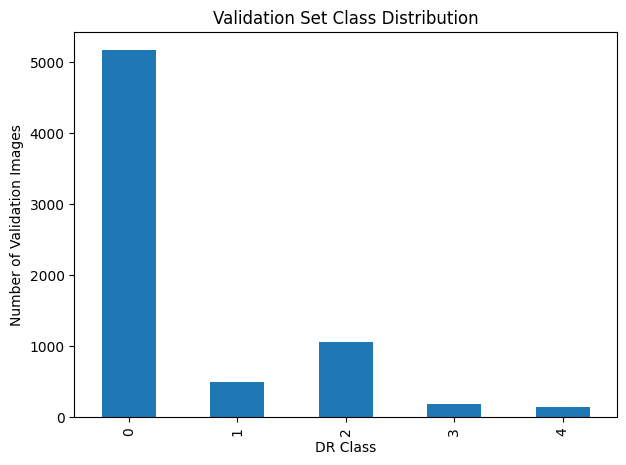

In [25]:
val_df["level"].value_counts().sort_index().plot(kind="bar", figsize=(7,5))
plt.xlabel("DR Class")
plt.ylabel("Number of Validation Images")
plt.title("Validation Set Class Distribution")
plt.show()

## Pre-class Error rate plot

In [ ]:
results_df = pd.DataFrame({
    "true": val_labels,
    "pred": val_preds
})
results_df["correct"] = results_df["true"] == results_df["pred"]

class_stats = results_df.groupby("true")["correct"].agg(["sum", "count"])
class_stats["incorrect"] = class_stats["count"] - class_stats["sum"]

error_rate = 1 - (class_stats["sum"] / class_stats["count"])

plt.figure(figsize=(7,5))
plt.bar(error_rate.index.astype(str), error_rate.values)
plt.xlabel("Class")
plt.ylabel("Error Rate")
plt.ylim(0, 1)
plt.title("Per-Class Error Rate")
plt.show()


## Pre-class Recall

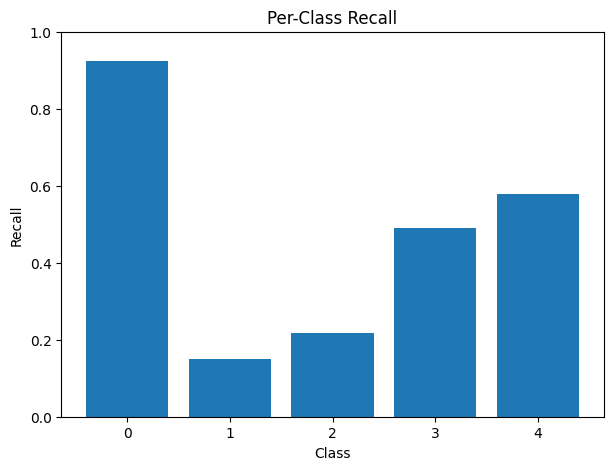

In [29]:
class_recall = class_stats["sum"] / class_stats["count"]

plt.figure(figsize=(7,5))
plt.bar(class_recall.index.astype(str), class_recall.values)
plt.xlabel("Class")
plt.ylabel("Recall")
plt.ylim(0,1)
plt.title("Per-Class Recall")
plt.show()

## Per-class Precision / Recall / F1 Bar Chart

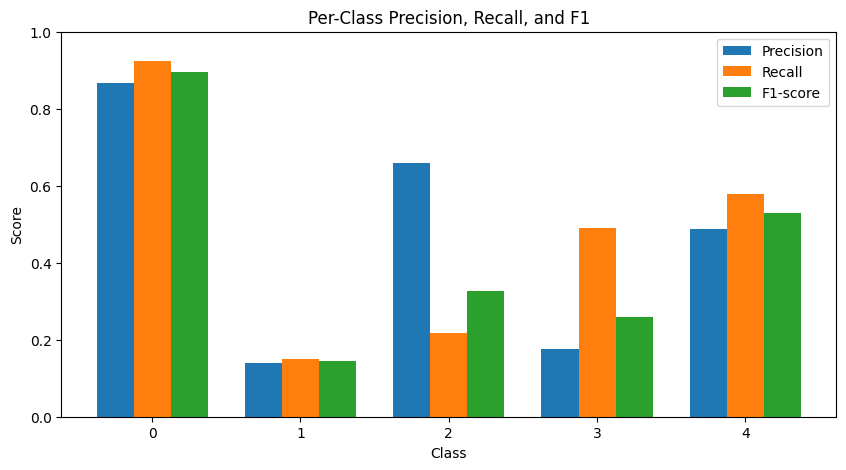

In [30]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

precision, recall, f1, _ = precision_recall_fscore_support(
    val_labels, val_preds, labels=[0,1,2,3,4], zero_division=0
)

classes = ['0', '1', '2', '3', '4']
x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-score')

plt.xticks(x, classes)
plt.ylim(0, 1)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Per-Class Precision, Recall, and F1")
plt.legend()
plt.show()

## Class Distribution Plot

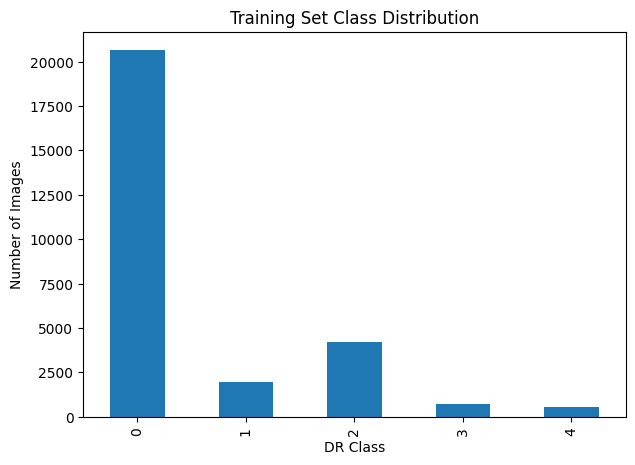

In [31]:
train_df["level"].value_counts().sort_index().plot(kind="bar", figsize=(7,5))
plt.xlabel("DR Class")
plt.ylabel("Number of Images")
plt.title("Training Set Class Distribution")
plt.show()

## Prediction distribution vs true distribution

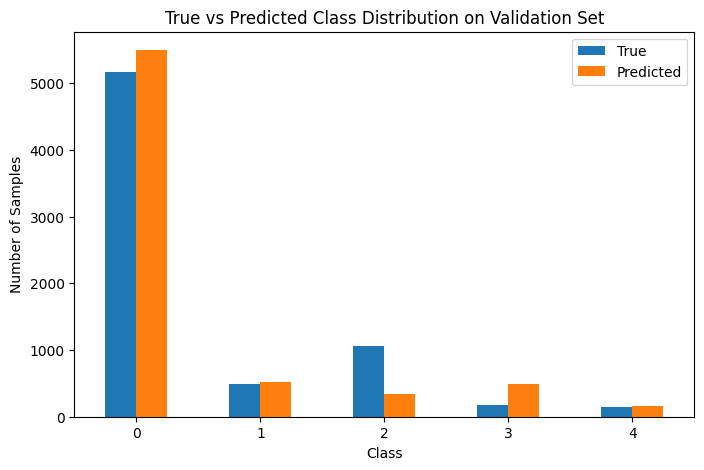

In [32]:
true_counts = pd.Series(val_labels).value_counts().sort_index()
pred_counts = pd.Series(val_preds).value_counts().sort_index()

dist_df = pd.DataFrame({
    "True": true_counts,
    "Predicted": pred_counts
}).fillna(0)

dist_df.plot(kind="bar", figsize=(8,5))
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("True vs Predicted Class Distribution on Validation Set")
plt.xticks(rotation=0)
plt.show()

## Sample Predictions Grid

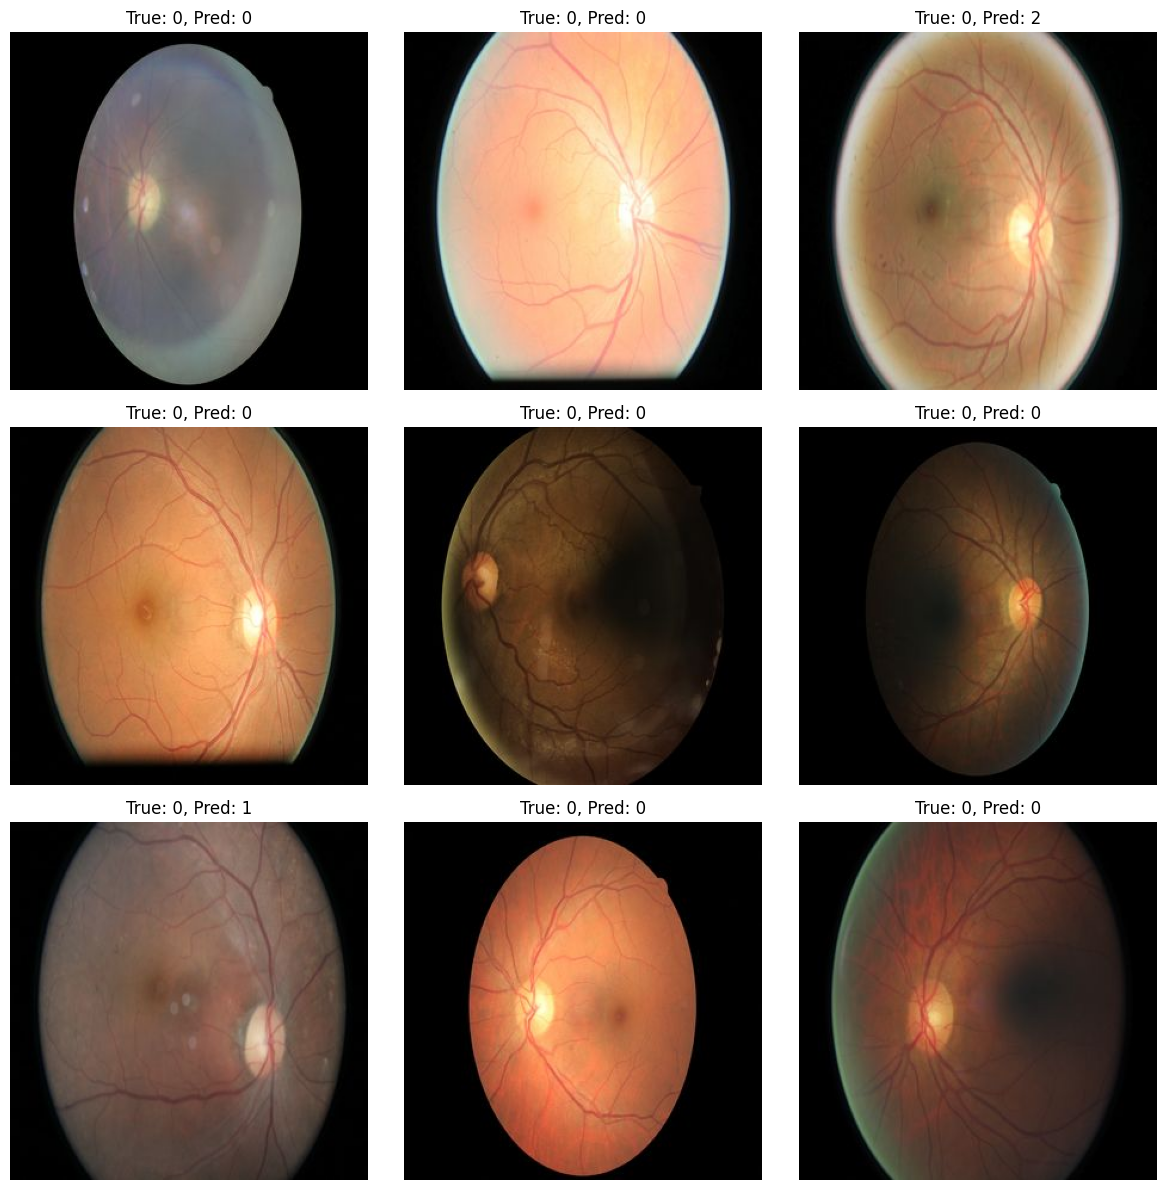

In [33]:
import random
from PIL import Image

sample_indices = random.sample(range(len(val_df)), 9)

plt.figure(figsize=(12, 12))
for i, idx in enumerate(sample_indices, 1):
    row = val_df.iloc[idx]
    img = Image.open(row["image_path"]).convert("RGB")

    # you need corresponding prediction list aligned with val_df
    true_label = row["level"]
    pred_label = val_preds[idx]

    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(f"True: {true_label}, Pred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Misclassified Predictions Grid

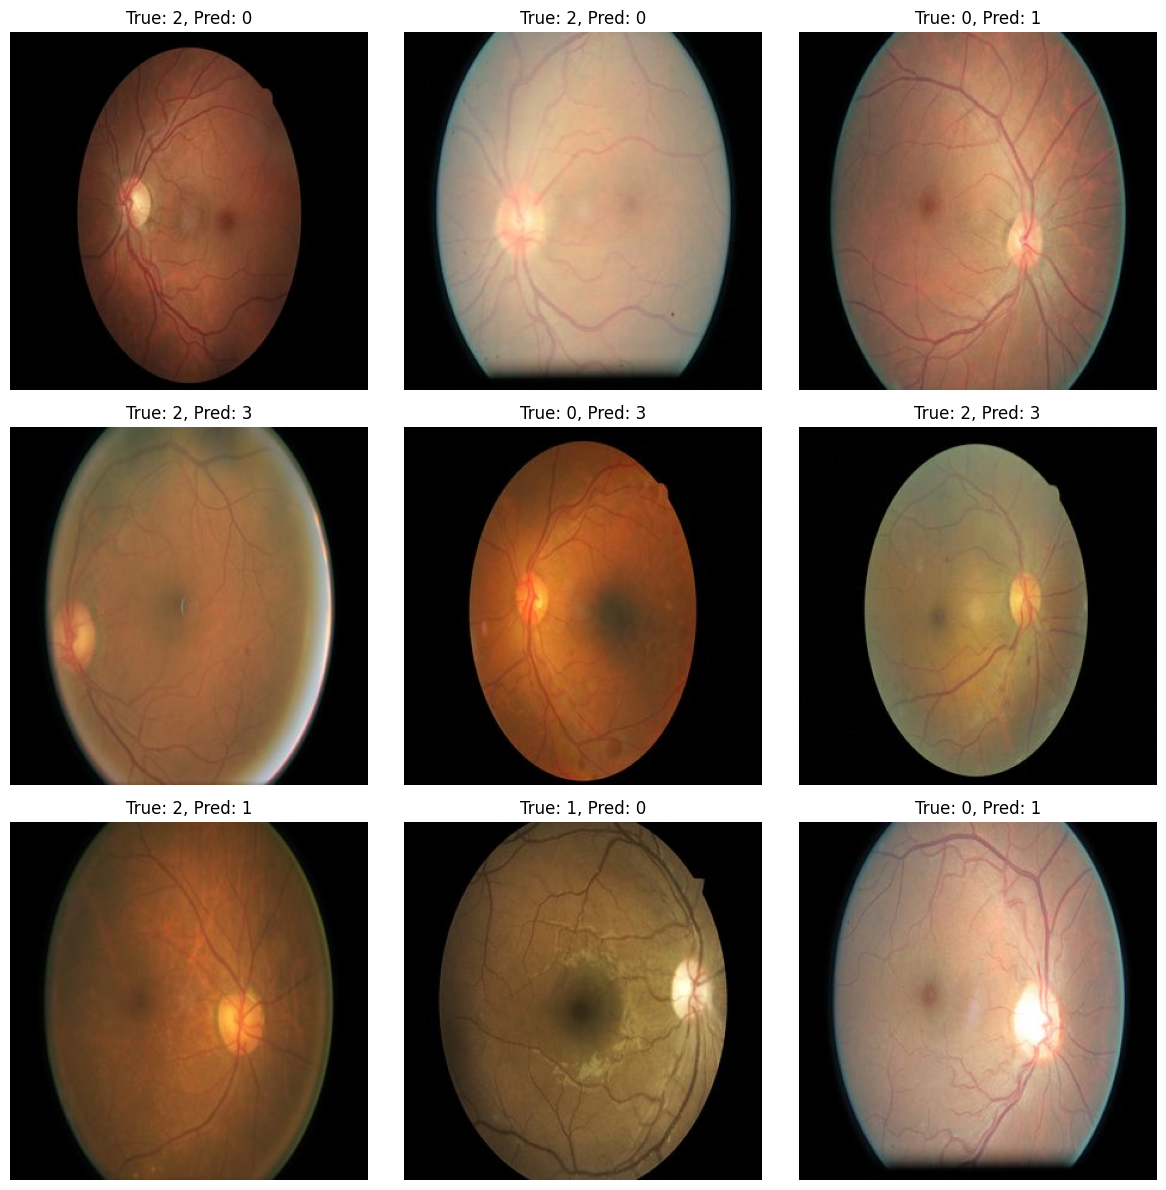

In [34]:
mis_idx = [i for i, (t, p) in enumerate(zip(val_labels, val_preds)) if t != p][:9]

plt.figure(figsize=(12, 12))
for i, idx in enumerate(mis_idx, 1):
    row = val_df.iloc[idx]
    img = Image.open(row["image_path"]).convert("RGB")

    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(f"True: {row['level']}, Pred: {val_preds[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
results_df = pd.DataFrame({
    "true": val_labels,
    "pred": val_preds
})

mistakes = results_df[results_df["true"] != results_df["pred"]]
pair_counts = mistakes.groupby(["true", "pred"]).size().sort_values(ascending=False)

print(pair_counts.head(10))

true  pred
1     0       378
2     3       332
      0       319
0     1       289
2     1       150
0     2        76
3     4        54
4     3        38
2     4        28
1     2        25
dtype: int64


## Misclassification flow heatmap

In [ ]:
cm = confusion_matrix(val_labels, val_final_preds, labels=[0, 1, 2, 3, 4])
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_offdiag,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=[0, 1, 2, 3, 4],
    yticklabels=[0, 1, 2, 3, 4]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Misclassification Heatmap (Ordinal Predictions)")
plt.show()


## Correct vs incorrect predictions by class

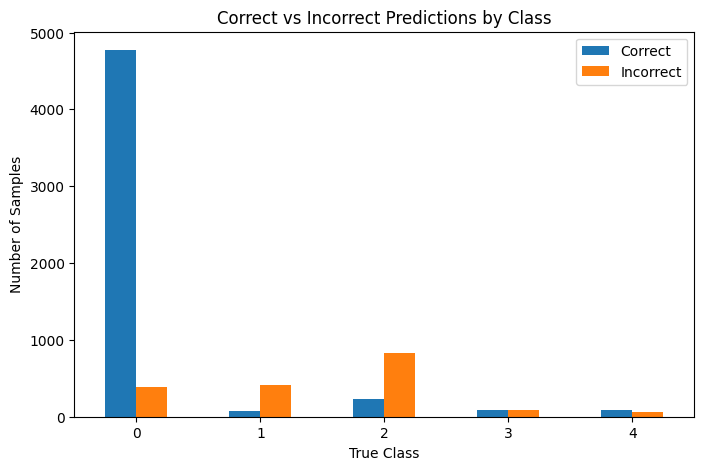

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results_df = pd.DataFrame({
    "true": val_labels,
    "pred": val_preds
})
results_df["correct"] = results_df["true"] == results_df["pred"]

class_stats = results_df.groupby("true")["correct"].agg(["sum", "count"])
class_stats["incorrect"] = class_stats["count"] - class_stats["sum"]

class_stats[["sum", "incorrect"]].plot(
    kind="bar",
    figsize=(8,5)
)
plt.xlabel("True Class")
plt.ylabel("Number of Samples")
plt.title("Correct vs Incorrect Predictions by Class")
plt.legend(["Correct", "Incorrect"])
plt.xticks(rotation=0)
plt.show()

## Generalised Gap Plot

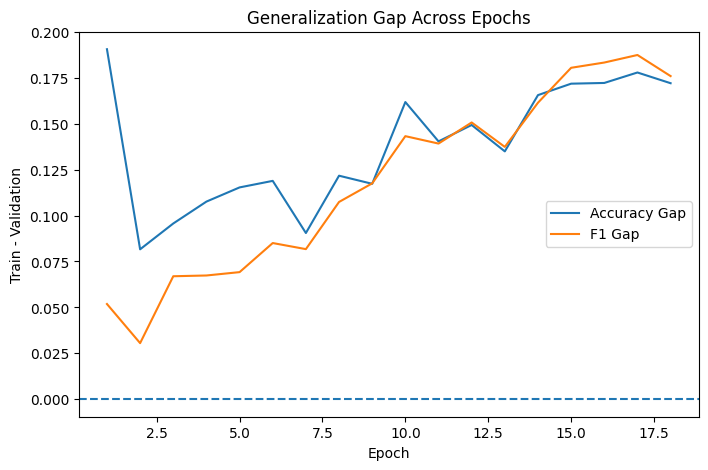

In [38]:
gap_acc = np.array(history_df["train_acc"]) - np.array(history_df["val_acc"])
gap_f1 = np.array(history_df["train_f1"]) - np.array(history_df["val_f1"])

epochs = range(1, len(gap_acc) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, gap_acc, label="Accuracy Gap")
plt.plot(epochs, gap_f1, label="F1 Gap")
plt.axhline(0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Train - Validation")
plt.title("Generalization Gap Across Epochs")
plt.legend()
plt.show()

## Epoch-to-Epoch Improvement Graphs

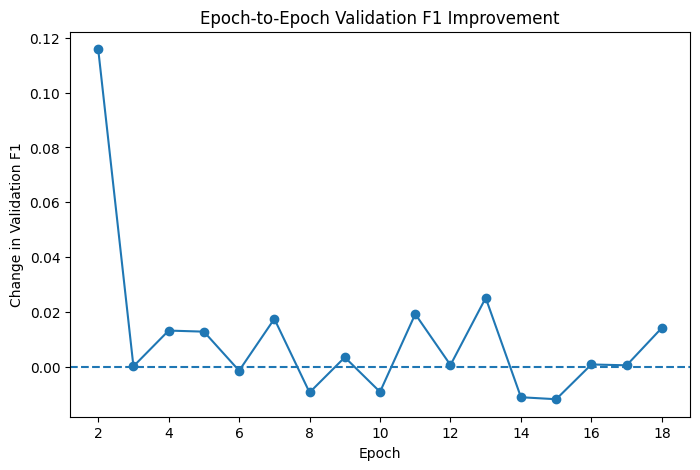

In [39]:
val_f1 = np.array(history_df["val_f1"])
delta_val_f1 = np.diff(val_f1)

plt.figure(figsize=(8,5))
plt.plot(range(2, len(val_f1)+1), delta_val_f1, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Change in Validation F1")
plt.title("Epoch-to-Epoch Validation F1 Improvement")
plt.show()

In [ ]:
val_loss = np.array(history_df["val_loss"])
delta_val_loss = np.diff(val_loss)

plt.figure(figsize=(8,5))
plt.plot(range(2, len(val_loss)+1), delta_val_loss, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Change in Validation Loss")
plt.title("Epoch-to-Epoch Validation Loss Improvement")
plt.show()


In [ ]:
val_acc = np.array(history_df["val_acc"])
delta_val_acc = np.diff(val_acc)

plt.figure(figsize=(8,5))
plt.plot(range(2, len(val_acc)+1), delta_val_acc, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Change in Validation Accuracy")
plt.title("Epoch-to-Epoch Validation Accuracy Improvement")
plt.show()


In [ ]:
img, ordinal_target, label = train_dataset[0]
print(type(img), img.shape, ordinal_target, label)


In [ ]:
batch = next(iter(train_loader))
images, ordinal_targets, labels = batch
print(images.shape, ordinal_targets.shape, labels.shape)


In [ ]:
def predict_ordinal_labels(model, loader, device, thresholds=None):
    """Return final class labels 0..4 from ordinal sigmoid outputs."""
    model.eval()
    preds = []
    probs_all = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Predicting", leave=False, dynamic_ncols=True):
            images = batch[0].to(device, non_blocking=True)
            if USE_CHANNELS_LAST and device.type == "cuda":
                images = images.contiguous(memory_format=torch.channels_last)

            with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
                logits = model(images)
                probs = ordinal_logits_to_probs(logits)

            batch_preds = ordinal_probs_to_class(
                probs,
                thresholds=0.5 if thresholds is None else thresholds
            )
            preds.extend(batch_preds.detach().cpu().numpy())
            probs_all.extend(probs.detach().cpu().numpy())

    return np.asarray(preds, dtype=np.int64), np.asarray(probs_all, dtype=np.float32)


# Example for a future unlabeled/test loader:
# test_preds, test_ordinal_probs = predict_ordinal_labels(model, test_loader, DEVICE, thresholds=saved_thresholds)
